In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_lfw_people
from sklearn.model_selection import train_test_split

In [2]:
lfw_people = fetch_lfw_people(min_faces_per_person=30, resize=1.0)

In [3]:
unique_targets = np.unique(lfw_people.target)
selected_ids = unique_targets[:5]
mask = np.isin(lfw_people.target, selected_ids)

In [4]:
X = lfw_people.images[mask]
y = lfw_people.target[mask]
target_names = lfw_people.target_names[selected_ids]

In [5]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Общее количество изображений: {len(X)}")
print(f"Количество личностей: {len(target_names)}")
for i, name in enumerate(target_names):
    print(f"Личность {i}: {name} ({np.sum(y == selected_ids[i])} изображений)")

Общее количество изображений: 229
Количество личностей: 5
Личность 0: Alejandro Toledo (39 изображений)
Личность 1: Alvaro Uribe (35 изображений)
Личность 2: Andre Agassi (36 изображений)
Личность 3: Ariel Sharon (77 изображений)
Личность 4: Arnold Schwarzenegger (42 изображений)


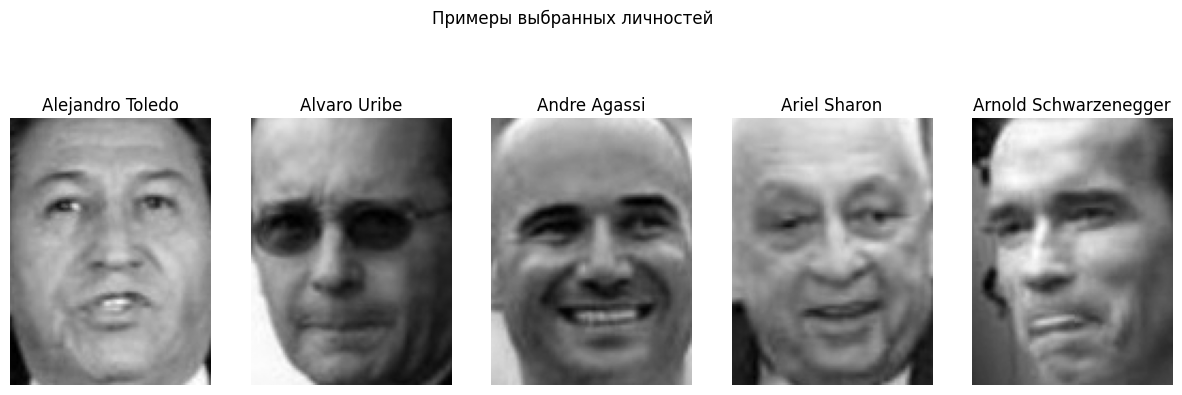

In [6]:
# Визуализация одного примера для каждой личности
plt.figure(figsize=(15, 5))
for i in range(5):
    plt.subplot(1, 5, i + 1)
    idx = np.where(y == selected_ids[i])[0][0]
    plt.imshow(X[idx], cmap='gray')
    plt.title(target_names[i])
    plt.axis('off')
plt.suptitle('Примеры выбранных личностей')
plt.show()


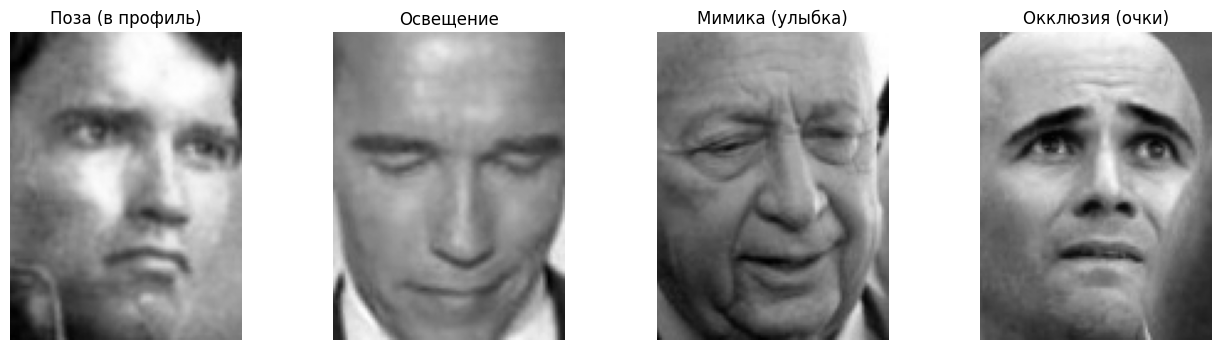

In [7]:
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
variations = ['Поза (в профиль)', 'Освещение', 'Мимика (улыбка)', 'Окклюзия (очки)']
example_indices = [10, 25, 40, 55]

for i, ax in enumerate(axes):
    ax.imshow(X[example_indices[i]], cmap='gray')
    ax.set_title(variations[i])
    ax.axis('off')
plt.show()

In [8]:
import cv2

In [9]:
# Загружаем предобученный классификатор для лиц
face_cascade = cv2.CascadeClassifier(cv2.data.haarcascades + 'haarcascade_frontalface_default.xml')

In [10]:
def detect_and_crop(img, size=(64, 64)):
    # LFW изображения уже в градациях серого или нормализованы, приведем к 8-бит для OpenCV
    img_uint8 = (img * 255).astype(np.uint8) if img.max() <= 1.0 else img.astype(np.uint8)
    faces = face_cascade.detectMultiScale(img_uint8, 1.1, 4)

    if len(faces) > 0:
        (x, y, w, h) = faces[0]
        crop = img[y:y+h, x:x+w]
        return cv2.resize(crop, size), (x, y, w, h)
    return cv2.resize(img, size), None

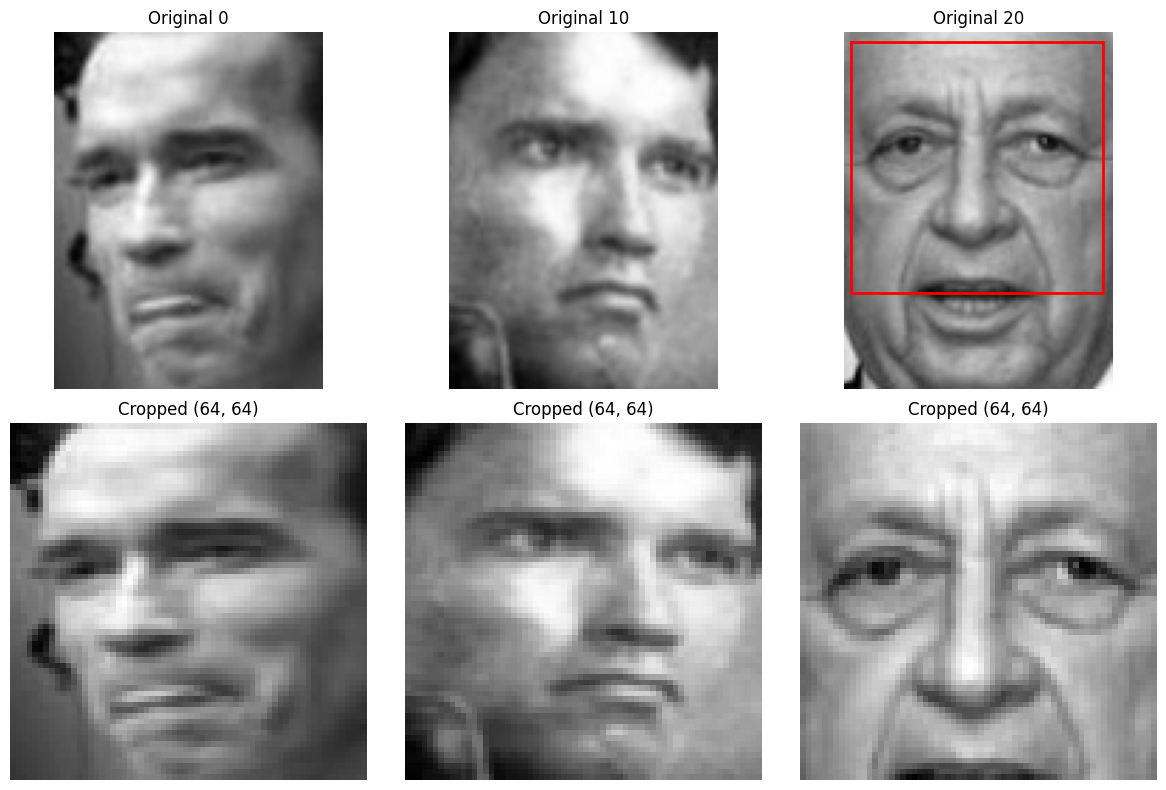

In [11]:
# Обработаем несколько примеров
sample_indices = [0, 10, 20]
plt.figure(figsize=(12, 8))

cropped_faces = []
for i, idx in enumerate(sample_indices):
    original = X[idx]
    cropped, bbox = detect_and_crop(original)
    cropped_faces.append(cropped)

    # Оригинал с рамкой
    plt.subplot(2, 3, i + 1)
    plt.imshow(original, cmap='gray')
    if bbox:
        x, y, w, h = bbox
        plt.gca().add_patch(plt.Rectangle((x, y), w, h, edgecolor='red', facecolor='none', lw=2))
    plt.title(f'Original {idx}')
    plt.axis('off')

    # Обрезанное лицо
    plt.subplot(2, 3, i + 4)
    plt.imshow(cropped, cmap='gray')
    plt.title(f'Cropped {cropped.shape}')
    plt.axis('off')

plt.tight_layout()
plt.show()

In [12]:
# Подготовка всех данных для следующего этапа (CNN)
X_train_cropped = np.array([detect_and_crop(img)[0] for img in X_train])
X_test_cropped = np.array([detect_and_crop(img)[0] for img in X_test])

print(f"Форма обучающей выборки после обработки: {X_train_cropped.shape}")
print(f"Форма тестовой выборки после обработки: {X_test_cropped.shape}")

Форма обучающей выборки после обработки: (183, 64, 64)
Форма тестовой выборки после обработки: (46, 64, 64)


In [13]:
import tensorflow as tf
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input
from sklearn.decomposition import PCA
from sklearn.metrics.pairwise import cosine_similarity

In [14]:
# Загрузка предобученной модели без верхнего слоя
base_model = MobileNetV2(weights='imagenet', include_top=False, input_shape=(64, 64, 3), pooling='avg')

/tmp/ipykernel_3244/3827813435.py:2: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base_model = MobileNetV2(weights='imagenet', include_top=False, input_shape=(64, 64, 3), pooling='avg')


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


In [15]:
def get_embeddings(images):
    images_rgb = np.repeat(images[..., np.newaxis], 3, axis=-1)
    images_preprocessed = preprocess_input(images_rgb * 255.0)
    return base_model.predict(images_preprocessed)

In [16]:
# Извлекаем признаки
print("Извлечение признаков...")
emb_train = get_embeddings(X_train_cropped)
emb_test = get_embeddings(X_test_cropped)

print(f"Размерность вектора признаков: {emb_train.shape[1]}")

Извлечение признаков...
6/6 ━━━━━━━━━━━━━━━━━━━━ 25s 2s/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 15s 15s/step
Размерность вектора признаков: 1280


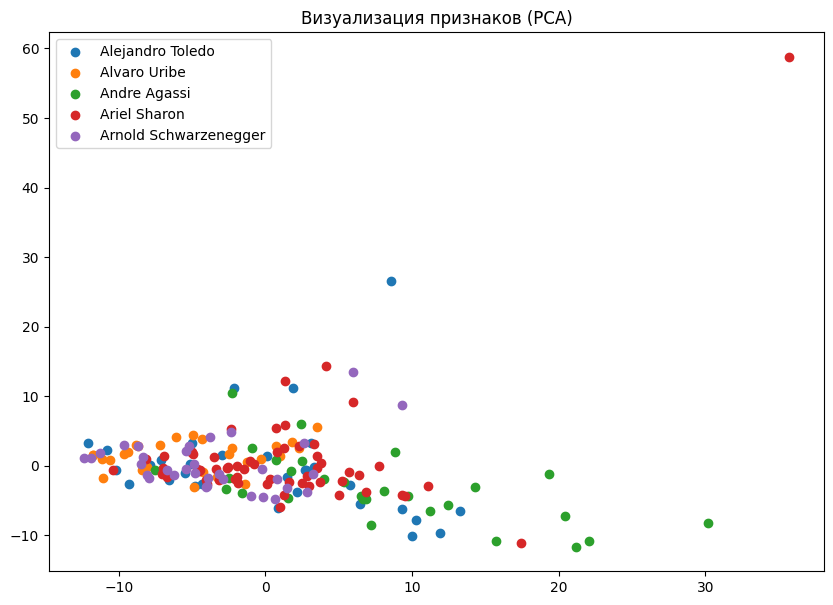

In [17]:
# Визуализация распределения признаков через PCA
pca = PCA(n_components=2)
emb_pca = pca.fit_transform(emb_train)

plt.figure(figsize=(10, 7))
for i in range(len(target_names)):
    mask_i = y_train == selected_ids[i]
    plt.scatter(emb_pca[mask_i, 0], emb_pca[mask_i, 1], label=target_names[i])
plt.legend()
plt.title('Визуализация признаков (PCA)')
plt.show()

In [18]:
def predict_face(test_emb, train_embs, train_labels, top_k=3):
    similarities = cosine_similarity(test_emb.reshape(1, -1), train_embs)[0]
    top_indices = np.argsort(similarities)[::-1][:top_k]
    return train_labels[top_indices], similarities[top_indices]

In [19]:
# Тестирование
y_pred = []
y_pred_top3 = []

for i in range(len(emb_test)):
    preds, sims = predict_face(emb_test[i], emb_train, y_train)
    y_pred.append(preds[0])
    y_pred_top3.append(preds)

y_pred = np.array(y_pred)

In [20]:
# Расчет метрик
accuracy = np.mean(y_pred == y_test)
rank3_acc = np.mean([y_test[i] in y_pred_top3[i] for i in range(len(y_test))])

print(f"Accuracy (Rank-1): {accuracy:.2%}")
print(f"Rank-3 Accuracy: {rank3_acc:.2%}")

Accuracy (Rank-1): 65.22%
Rank-3 Accuracy: 84.78%


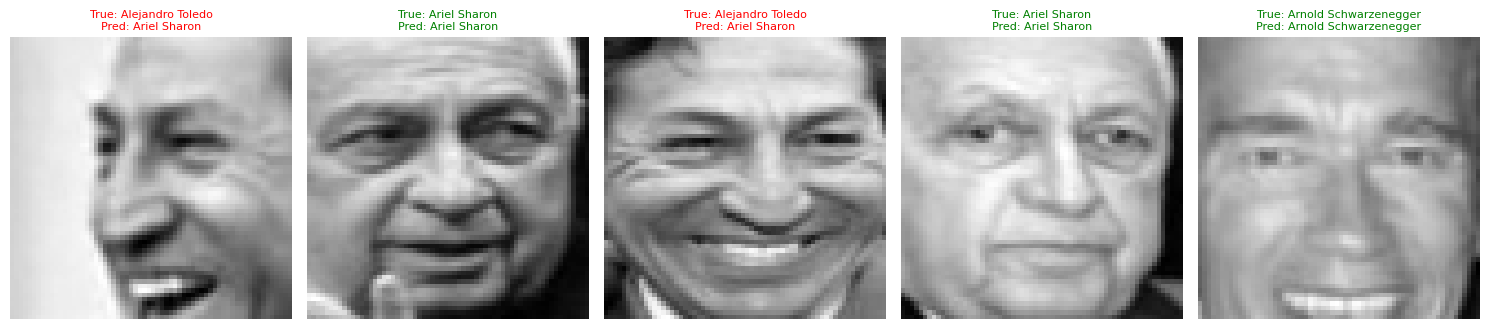

In [21]:
# Визуализация результатов
plt.figure(figsize=(15, 8))
for i in range(5):
    plt.subplot(2, 5, i+1)
    plt.imshow(X_test_cropped[i], cmap='gray')
    color = 'green' if y_pred[i] == y_test[i] else 'red'
    plt.title(f"True: {target_names[np.where(selected_ids==y_test[i])[0][0]]}\nPred: {target_names[np.where(selected_ids==y_pred[i])[0][0]]}", color=color, fontsize=8)
    plt.axis('off')
plt.tight_layout()
plt.show()

In [22]:
import itertools
from sklearn.metrics import precision_recall_fscore_support, accuracy_score
import pandas as pd

In [23]:
# 1. Генерация пар для верификации
def generate_pairs(embs, labels, n_pairs=500):
    same_pairs = []
    diff_pairs = []
    n = len(labels)

    # Генерируем случайные пары
    indices = np.arange(n)
    while len(same_pairs) < n_pairs or len(diff_pairs) < n_pairs:
        i, j = np.random.choice(indices, 2, replace=False)
        sim = cosine_similarity(embs[i].reshape(1, -1), embs[j].reshape(1, -1))[0][0]
        if labels[i] == labels[j] and len(same_pairs) < n_pairs:
            same_pairs.append(sim)
        elif labels[i] != labels[j] and len(diff_pairs) < n_pairs:
            diff_pairs.append(sim)

    return np.array(same_pairs), np.array(diff_pairs)

same_sims, diff_sims = generate_pairs(emb_test, y_test, n_pairs=100)

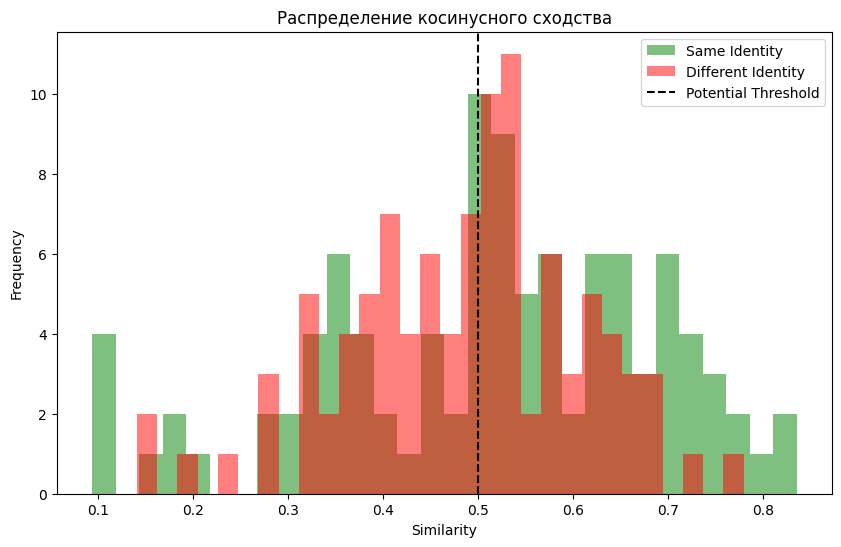

In [24]:
# 2. Визуализация распределения
plt.figure(figsize=(10, 6))
plt.hist(same_sims, bins=30, alpha=0.5, label='Same Identity', color='green')
plt.hist(diff_sims, bins=30, alpha=0.5, label='Different Identity', color='red')
plt.axvline(x=0.5, color='black', linestyle='--', label='Potential Threshold')
plt.title('Распределение косинусного сходства')
plt.xlabel('Similarity')
plt.ylabel('Frequency')
plt.legend()
plt.show()

In [25]:
# 3. Нахождение оптимального порога
thresholds = np.linspace(0, 1, 100)
best_acc = 0
best_th = 0

for th in thresholds:
    acc = (np.sum(same_sims >= th) + np.sum(diff_sims < th)) / (len(same_sims) + len(diff_sims))
    if acc > best_acc:
        best_acc = acc
        best_th = th

print(f"Оптимальный порог: {best_th:.2f}")
print(f"Точность верификации при пороге: {best_acc:.2%}")

Оптимальный порог: 0.62
Точность верификации при пороге: 59.50%


In [26]:
# Расчет метрик для задачи идентификации (Task 4)
precision, recall, f1, _ = precision_recall_fscore_support(y_test, y_pred, average='weighted')
ident_acc = accuracy_score(y_test, y_pred)

metrics_data = {
    'Metric': ['Accuracy', 'Precision (Weighted)', 'Recall (Weighted)', 'F1-Score (Weighted)'],
    'Value': [ident_acc, precision, recall, f1]
}

metrics_df = pd.DataFrame(metrics_data)
print("Таблица метрик для задачи идентификации:")
display(metrics_df)

print("\nРазличие:")
print("Идентификация (1-из-N): Сравнение одного лица со всей базой для поиска личности.")
print("Верификация (1-из-1): Проверка, принадлежит ли лицо конкретному человеку (сравнение пары).")

Таблица метрик для задачи идентификации:


,Metric,Value
0,Accuracy,0.652174
1,Precision (Weighted),0.646771
2,Recall (Weighted),0.652174
3,F1-Score (Weighted),0.640536



Различие:
Идентификация (1-из-N): Сравнение одного лица со всей базой для поиска личности.
Верификация (1-из-1): Проверка, принадлежит ли лицо конкретному человеку (сравнение пары).


In [27]:
from sklearn.decomposition import PCA
from sklearn.neighbors import KNeighborsClassifier

In [28]:
X_train_flat = X_train_cropped.reshape(len(X_train_cropped), -1)
X_test_flat = X_test_cropped.reshape(len(X_test_cropped), -1)

In [29]:
# Снижаем размерность до 50 компонент
pca_classic = PCA(n_components=50, whiten=True)
X_train_pca = pca_classic.fit_transform(X_train_flat)
X_test_pca = pca_classic.transform(X_test_flat)

In [30]:
# Классификатор для PCA признаков
knn = KNeighborsClassifier(n_neighbors=1)
knn.fit(X_train_pca, y_train)
y_pred_pca = knn.predict(X_test_pca)

accuracy_pca = accuracy_score(y_test, y_pred_pca)

print(f"Результаты сравнения:")
print(f"1. CNN (MobileNetV2): Accuracy = {accuracy:.2%}, Размерность = {emb_train.shape[1]}")
print(f"2. PCA (Classical): Accuracy = {accuracy_pca:.2%}, Размерность = 50")

print("\nПреимущество CNN: Устойчивость к изменениям освещения и позы за счет глубоких иерархических признаков.")
print("Преимущество PCA: Высокая скорость вычислений и низкие требования к ресурсам.")

Результаты сравнения:
1. CNN (MobileNetV2): Accuracy = 65.22%, Размерность = 1280
2. PCA (Classical): Accuracy = 63.04%, Размерность = 50

Преимущество CNN: Устойчивость к изменениям освещения и позы за счет глубоких иерархических признаков.
Преимущество PCA: Высокая скорость вычислений и низкие требования к ресурсам.


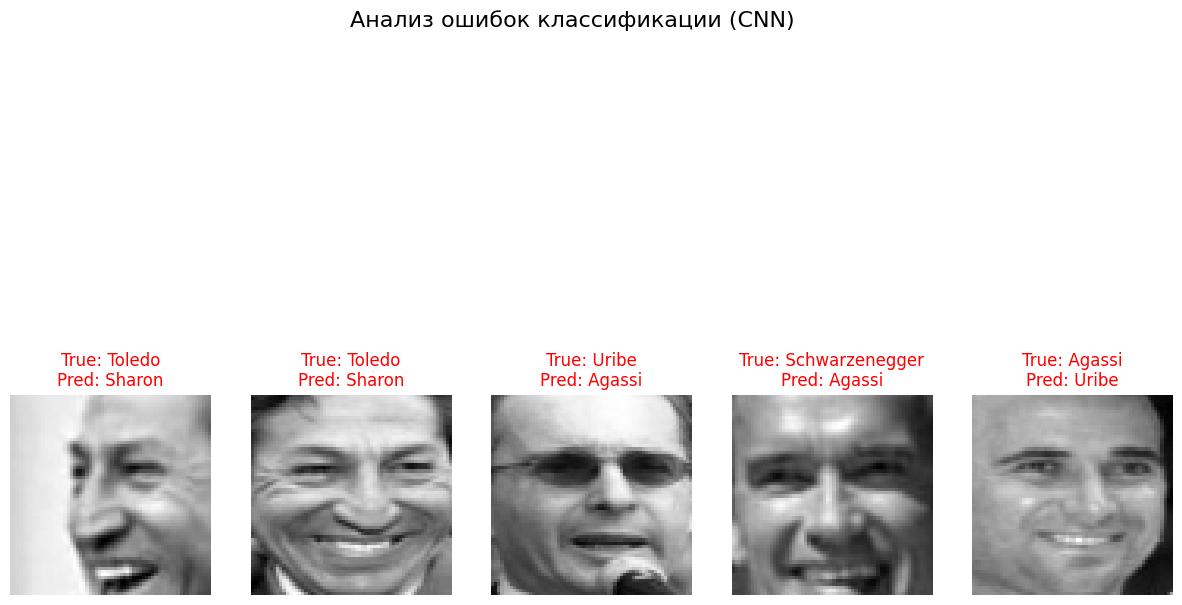

Анализ причин ошибок:
1. Поза: Многие ошибки возникают при сильном повороте головы (профиль).
2. Освещение: Тень на половине лица мешает извлечению стабильных признаков.
3. Разрешение: При сильном обрезке (crop) теряются мелкие детали лица.


In [31]:
# Поиск индексов неверных предсказаний
errors_idx = np.where(y_pred != y_test)[0]

plt.figure(figsize=(15, 10))
n_errors = min(len(errors_idx), 5)

for i in range(n_errors):
    idx = errors_idx[i]
    plt.subplot(1, n_errors, i + 1)
    plt.imshow(X_test_cropped[idx], cmap='gray')

    true_name = target_names[np.where(selected_ids == y_test[idx])[0][0]]
    pred_name = target_names[np.where(selected_ids == y_pred[idx])[0][0]]

    plt.title(f"True: {true_name.split()[-1]}\nPred: {pred_name.split()[-1]}", color='red')
    plt.axis('off')

plt.suptitle('Анализ ошибок классификации (CNN)', fontsize=16)
plt.show()

print("Анализ причин ошибок:")
print("1. Поза: Многие ошибки возникают при сильном повороте головы (профиль).")
print("2. Освещение: Тень на половине лица мешает извлечению стабильных признаков.")
print("3. Разрешение: При сильном обрезке (crop) теряются мелкие детали лица.")

In [32]:
import time

In [33]:
# 1. Замер для CNN (MobileNetV2)
start_time = time.time()
# Извлекаем признак для одного изображения
sample_img = X_test_cropped[0:1]
sample_emb = get_embeddings(sample_img)
# Предсказание
_ = predict_face(sample_emb[0], emb_train, y_train)
cnn_time = time.time() - start_time

1/1 ━━━━━━━━━━━━━━━━━━━━ 13s 13s/step


In [34]:
# 2. Замер для PCA
start_time = time.time()
# Сплющиваем и снижаем размерность
sample_flat = sample_img.reshape(1, -1)
sample_pca = pca_classic.transform(sample_flat)
# Предсказание
_ = knn.predict(sample_pca)
pca_time = time.time() - start_time

print(f"Среднее время обработки одного изображения:")
print(f"CNN подход: {cnn_time:.4f} сек.")
print(f"PCA подход: {pca_time:.4f} сек.")

print(f"\nВывод: PCA работает в {cnn_time/pca_time:.1f} раз быстрее, так как не требует прогона через глубокие слои нейросети. Однако CNN обеспечивает более высокую точность в сложных условиях.")

Среднее время обработки одного изображения:
CNN подход: 13.4250 сек.
PCA подход: 0.0029 сек.

Вывод: PCA работает в 4689.3 раз быстрее, так как не требует прогона через глубокие слои нейросети. Однако CNN обеспечивает более высокую точность в сложных условиях.
